# strore sales initial exploration
* time intervals (for training and prediction)
* available data

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print('train', train['date'].min(), train['date'].max())
print('train', test['date'].min(), test['date'].max())

train 2013-01-01 2017-08-15
train 2017-08-16 2017-08-31


In [3]:
print(train.sample(5))

              id        date  store_nbr          family  sales  onpromotion
143915    143915  2013-03-22         47          BEAUTY    2.0            0
1926466  1926466  2015-12-20         12   PERSONAL CARE  279.0            0
2953501  2953501  2017-07-20          3       BABY CARE    1.0            0
2090947  2090947  2016-03-22         28       BABY CARE    0.0            0
389396    389396  2013-08-07         34  PREPARED FOODS   46.0            0


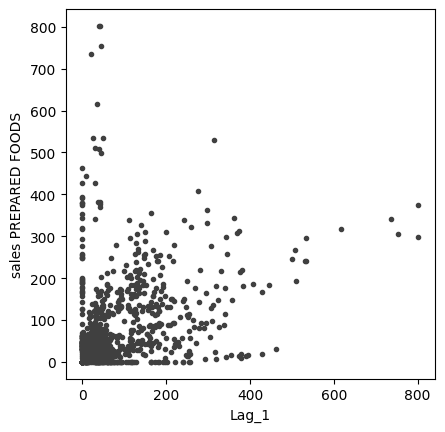

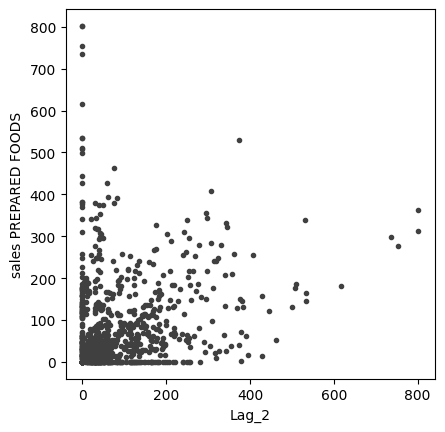

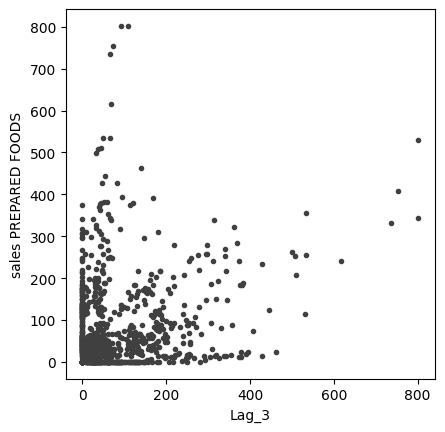

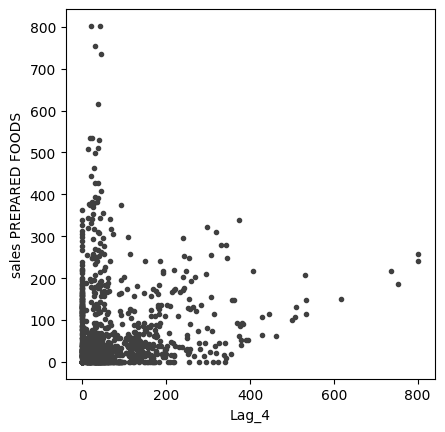

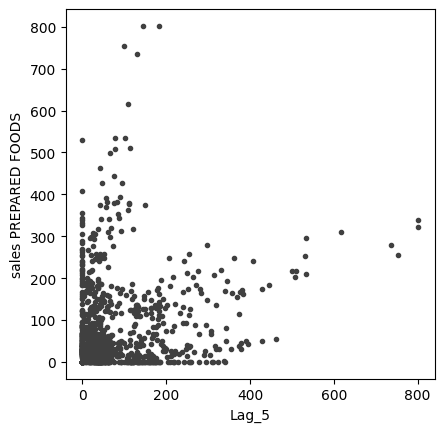

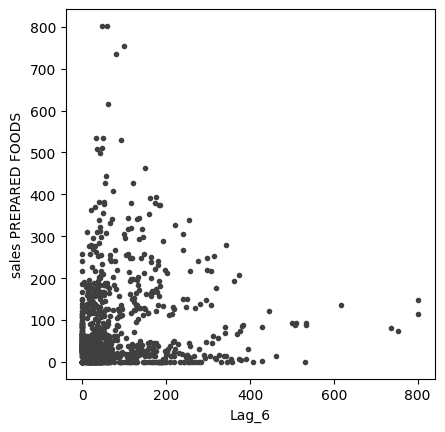

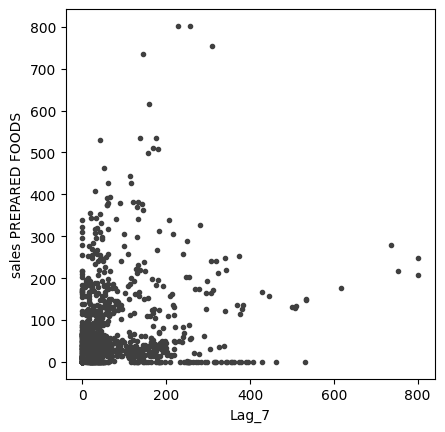

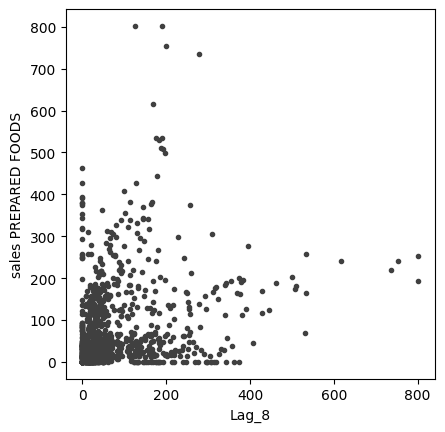

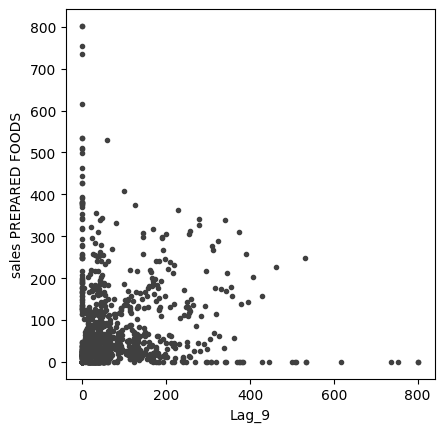

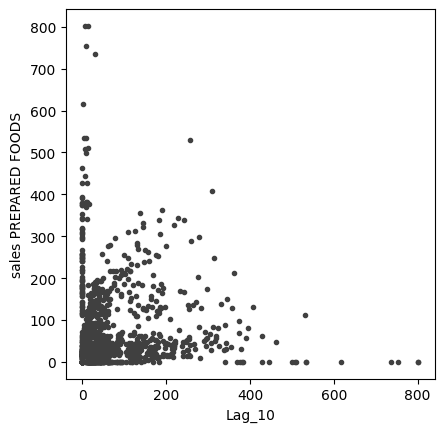

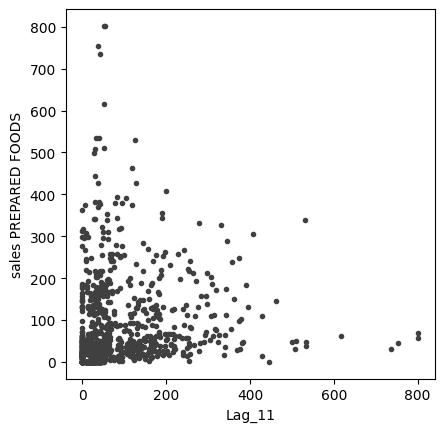

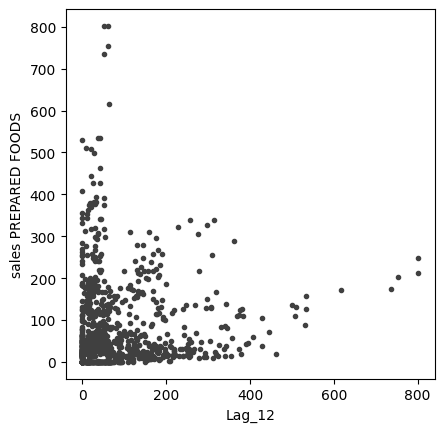

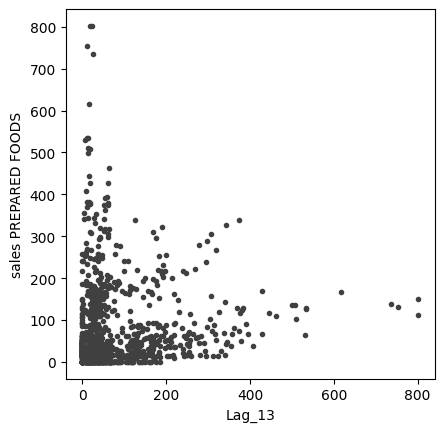

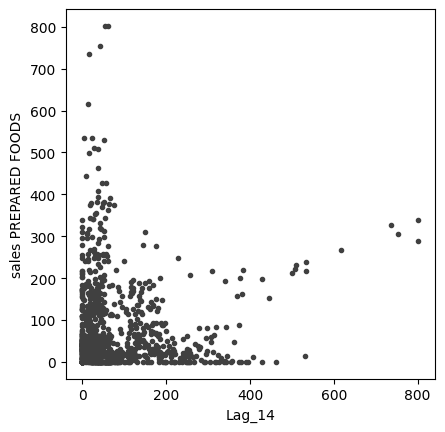

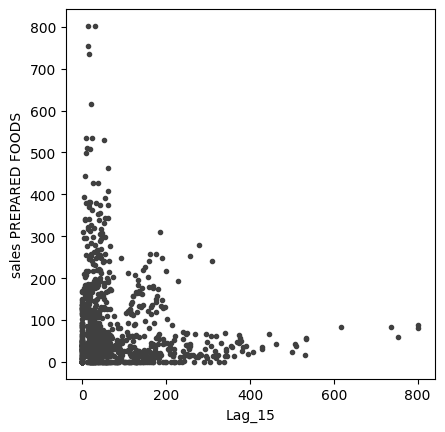

In [4]:
# check lag features
category = 'PREPARED FOODS'
df = train[train['family']==category].head(1000)

for i in range(1, 16):
    df[f"Lag_{i}"] = df['sales'].shift(i)
    
    fig, ax = plt.subplots()
    ax.plot(df[f"Lag_{i}"], df['sales'], '.', color='0.25')
    ax.set_aspect('equal')
    ax.set_ylabel(f"sales {category}")
    ax.set_xlabel(f"Lag_{i}")

<Axes: >

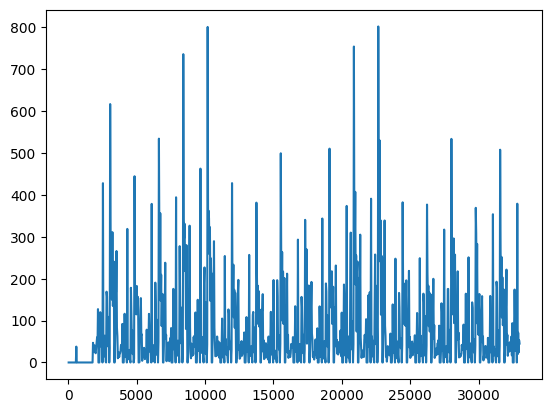

In [5]:
# check trend(s)
category = 'PREPARED FOODS'
df = train[train['family']==category].head(1000)

df['sales'].plot()

In [10]:
# annotations: https://stackoverflow.com/a/49238256/5769929
def seasonal_plot(X, y, period, freq, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    palette = sns.color_palette("husl", n_colors=X[period].nunique(),)
    ax = sns.lineplot(
        x=freq,
        y=y,
        hue=period,
        data=X,
        errorbar=('ci', False),
        ax=ax,
        palette=palette,
        legend=False,
    )
    ax.set_title(f"Seasonal Plot ({period}/{freq})")
    for line, name in zip(ax.lines, X[period].unique()):
        y_ = line.get_ydata()[-1]
        ax.annotate(
            name,
            xy=(1, y_),
            xytext=(6, 0),
            color=line.get_color(),
            xycoords=ax.get_yaxis_transform(),
            textcoords="offset points",
            size=14,
            va="center",
        )
    return ax


def plot_periodogram(ts, detrend='linear', ax=None):
    from scipy.signal import periodogram
    fs = pd.Timedelta("365D") / pd.Timedelta("1D")
    freqencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum',
    )
    if ax is None:
        _, ax = plt.subplots()
    ax.step(freqencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels(
        [
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Bimonthly (6)",
            "Monthly (12)",
            "Biweekly (26)",
            "Weekly (52)",
            "Semiweekly (104)",
        ],
        rotation=30,
    )
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")
    return ax

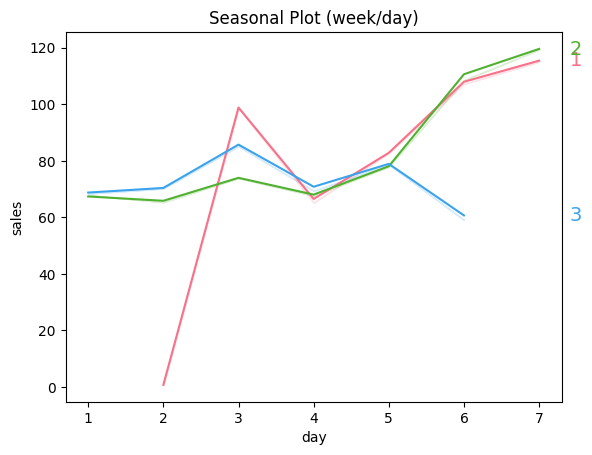

In [11]:
# seasons?
category = 'PREPARED FOODS'
df = train[train['family']==category].head(1000)

df["week"] = pd.to_datetime(df['date']).dt.isocalendar().week
df["day"] = pd.to_datetime(df['date']).dt.isocalendar().day
seasonal_plot(df, y='sales', period='week', freq='day');